In [2]:
# Importar librerías analíticas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el archivo CSV
df = pd.read_csv('ventas_ecommerce.csv')

# Mostrar las primeras filas para verificar la carga
df.head()

,ID_Cliente,Mes,Region,Canal_Marketing,Tipo_Contrato,Monto_Venta_USD,Costo_Adquisicion_CAC,Cliente_Retenido
0,CLI-001,Enero,LATAM,Google Ads,Mensual,150.5,25.0,Si
1,CLI-002,Enero,Norteamerica,Redes Sociales,Anual,450.0,40.0,Si
2,CLI-003,Enero,LATAM,Email Marketing,Mensual,85.0,12.0,No
3,CLI-004,Febrero,Europa,Google Ads,Mensual,210.0,30.0,Si
4,CLI-005,Febrero,LATAM,Redes Sociales,Mensual,95.0,35.0,No


In [10]:


# Agrupar datos por canal de marketing y calcular promedios
analisis_canales = df.groupby('Canal_Marketing')[['Monto_Venta_USD', 'Costo_Adquisicion_CAC']].mean().reset_index()

# Mostrar resultados ordenados por venta
analisis_canales.sort_values(by='Monto_Venta_USD', ascending=False)

,Canal_Marketing,Monto_Venta_USD,Costo_Adquisicion_CAC
3,Redes Sociales,355.000000,39.000000
2,Organico,355.000000,4.500000
1,Google Ads,145.166667,27.666667
0,Email Marketing,102.500000,13.500000


In [9]:

# Calcular porcentaje de clientes retenidos por tipo de contrato
retencion = pd.crosstab(df['Tipo_Contrato'], df['Cliente_Retenido'], normalize='index') * 100
retencion

Cliente_Retenido,No,Si
Tipo_Contrato,,
Anual,0.000000,100.000000
Mensual,42.857143,57.142857


In [11]:
# Agrupar por región y calcular el total e ingreso promedio
ventas_region = df.groupby('Region')['Monto_Venta_USD'].agg(['sum', 'mean']).reset_index()
ventas_region.columns = ['Region', 'Ventas_Totales', 'Venta_Promedio']
ventas_region

,Region,Ventas_Totales,Venta_Promedio
0,Europa,330.0,165.000000
1,LATAM,515.5,103.100000
2,Norteamerica,1570.0,523.333333


/tmp/ipykernel_5129/1166666801.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Canal_Marketing', y='Monto_Venta_USD', palette='Blues_d')


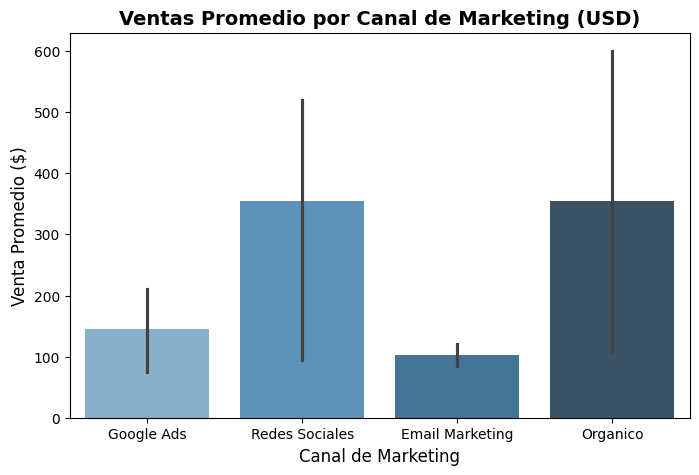

In [12]:
# Configurar estilo de gráfico
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Canal_Marketing', y='Monto_Venta_USD', palette='Blues_d')

# Título y etiquetas
plt.title('Ventas Promedio por Canal de Marketing (USD)', fontsize=14, fontweight='bold')
plt.xlabel('Canal de Marketing', fontsize=12)
plt.ylabel('Venta Promedio ($)', fontsize=12)

# Guardar la imagen para GitHub
plt.savefig('ventas_por_canal.png', bbox_inches='tight', dpi=300)
plt.show()